<a href="https://colab.research.google.com/github/sanchit-Thakur/ML-PROJECT/blob/main/Machine_Learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXAM FORM ERROR PREDICTOR

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

loading data




In [4]:
import pandas as pd
data_path = "/content/student_data.csv"
df = pd.read_csv(data_path)

print("--- First 5 Rows ---")
print(df.head(8))
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

--- First 5 Rows ---
  school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4   at_home   teacher   
1     GP   F   17       U     GT3       T     1     1   at_home     other   
2     GP   F   15       U     LE3       T     1     1   at_home     other   
3     GP   F   15       U     GT3       T     4     2    health  services   
4     GP   F   16       U     GT3       T     3     3     other     other   
5     GP   M   16       U     LE3       T     4     3  services     other   
6     GP   M   16       U     LE3       T     2     2     other     other   
7     GP   F   17       U     GT3       A     4     4     other   teacher   

   ... famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0  ...      4        3      4     1     1      3        6   5   6   6  
1  ...      5        3      3     1     1      3        4   5   5   6  
2  ...      4        3      2     2     3      3       10   7   8  10

In [5]:
# 2. Inspect Columns and Handle Missing Values
df = df.dropna()

In [6]:
print(df.shape)

(395, 33)


# 3. Define Features (X) and Target (y)
# Note: Common targets in student datasets are 'Final_Grade', 'Scores', 'G3', or similar.
# If your target column has a different name, replace it below:
# Defaults to the last column

In [7]:

target_column = df.columns[-1]
feature_columns = [col for col in df.columns if col != target_column]

In [8]:
# Select numerical features or encode categorical if necessary
X = df[feature_columns].select_dtypes(include=[np.number])
y = df[target_column]

In [9]:
print(f"\nFeatures used: {list(X.columns)}")
print(f"Target variable: {target_column}")


Features used: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Target variable: G3


In [10]:
# 4. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 5. Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
# 6. Make Predictions using the trained model
y_pred = model.predict(X_test)

In [20]:
# G3 target ko alag karke baki sab par One-Hot Encoding
X = pd.get_dummies(df.drop(columns=['G3']), drop_first=True)
y = df['G3']

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
q1 = df['absences'].quantile(0.25)
q3 = df['absences'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
df['absences'] = df['absences'].clip(upper=upper_bound)

In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("CV R² Mean:", cv_scores.mean(), "Std:", cv_scores.std())

CV R² Mean: 0.7842465150674716 Std: 0.060526373782248


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
print("RF Test R²:", rf.score(X_test, y_test))

RF Test R²: 0.8577917896102272


In [12]:
# Compare actual vs predicted values side-by-side
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': np.round(y_pred, 2),
    'Residual': np.round(y_test - y_pred, 2)
})
print("--- Sample of Predictions ---")
display(predictions_df.head(10))

--- Sample of Predictions ---


,Actual,Predicted,Residual
78,10,5.97,4.03
371,12,12.06,-0.06
248,5,3.16,1.84
55,10,9.14,0.86
390,9,7.69,1.31
223,13,12.01,0.99
42,18,18.96,-0.96
234,6,7.07,-1.07
316,0,7.40,-7.40
116,14,12.75,1.25


In [13]:
# Model coefficients
print(f"\nIntercept: {model.intercept_:.4f}")
for col, coef in zip(X.columns, model.coef_):
    print(f"Coefficient ({col}): {coef:.4f}")


Intercept: -0.4684
Coefficient (age): -0.1980
Coefficient (Medu): 0.0942
Coefficient (Fedu): -0.1883
Coefficient (traveltime): 0.1310
Coefficient (studytime): -0.0660
Coefficient (failures): -0.4163
Coefficient (famrel): 0.3346
Coefficient (freetime): 0.0106
Coefficient (goout): 0.1376
Coefficient (Dalc): -0.1050
Coefficient (Walc): 0.0618
Coefficient (health): 0.0591
Coefficient (absences): 0.0449
Coefficient (G1): 0.1607
Coefficient (G2): 0.9775


In [14]:
# 7. Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [15]:
print("\n--- Performance Metrics ---")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error):  {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


--- Performance Metrics ---
MAE  (Mean Absolute Error): 1.3482
MSE  (Mean Squared Error):  4.5038
RMSE (Root Mean Squared Error): 2.1222
R² Score: 0.7804


In [16]:
# 8. Visualization
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Actual vs. Predicted')

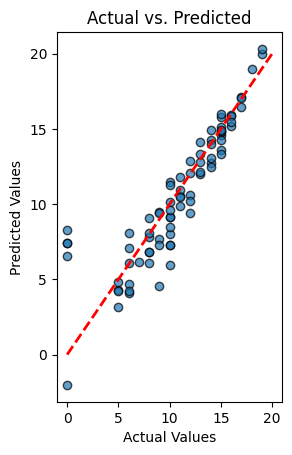

In [17]:
# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors="k")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted")

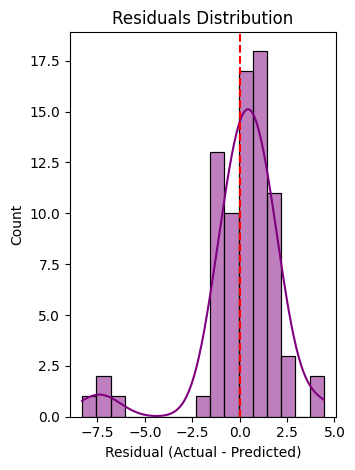

In [18]:
# Plot 2: Residual Distribution
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color="purple")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residuals Distribution")

plt.tight_layout()
plt.show()